NOTEBOOK-2 Feature Engineering / Feature Extraction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse
import json

In [2]:
df = pd.read_csv("/kaggle/input/datasets/yash934/cleaned-arxiv/cleaned_arxiv_full.csv")

print("Dataset Shape:", df.shape)
df.head()

/tmp/ipykernel_55/1355525628.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/yash934/cleaned-arxiv/cleaned_arxiv_full.csv")


Dataset Shape: (2968861, 4)


,id,title,categories,clean_abstract
0,704.0001,Calculation of prompt diphoton production cros...,hep-ph,fully differential calculation perturbative qu...
1,704.0002,Sparsity-certifying Graph Decompositions,math.CO cs.CG,describe new algorithm pebble game color use o...
2,704.0003,The evolution of the Earth-Moon system based o...,physics.gen-ph,evolution earth moon system describe dark matt...
3,704.0004,A determinant of Stirling cycle numbers counts...,math.CO,determinant stirling cycle number count unlabe...
4,704.0005,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,math.CA math.FA,paper compute norm dyadic grid result cons...


In [3]:
print("Missing values in clean_abstract:", df['clean_abstract'].isnull().sum())

# Remove rows with missing abstracts
df = df.dropna(subset=['clean_abstract'])

print("Dataset Shape After Cleaning:", df.shape)

Missing values in clean_abstract: 6
Dataset Shape After Cleaning: (2968855, 4)


In [4]:
texts = df['clean_abstract']

print("Total abstracts:", len(texts))

Total abstracts: 2968855


In [5]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    min_df=10,
    max_df=0.7,
    stop_words='english'
)

tfidf_matrix = tfidf_vectorizer.fit_transform(texts)

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (2968855, 10000)


In [6]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Total Features:", len(feature_names))
print("First 20 words:", feature_names[:20])

Total Features: 10000
First 20 words: ['abandon' 'abc' 'abdominal' 'abel' 'abelian' 'abell' 'aberration'
 'ability' 'ablation' 'able' 'abnormal' 'abnormality' 'aboard' 'abridge'
 'abrupt' 'abruptly' 'absence' 'absent' 'absolute' 'absolutely']


In [7]:
tfidf_means = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

top_indices = tfidf_means.argsort()[-20:][::-1]

top_words = [feature_names[i] for i in top_indices]
top_scores = tfidf_means[top_indices]

print("Top Important Words:")
print(top_words)

Top Important Words:
['model', 'result', 'method', 'state', 'field', 'datum', 'time', 'study', 'quantum', 'base', 'function', 'problem', 'propose', 'energy', 'theory', 'space', 'high', 'paper', 'present', 'approach']


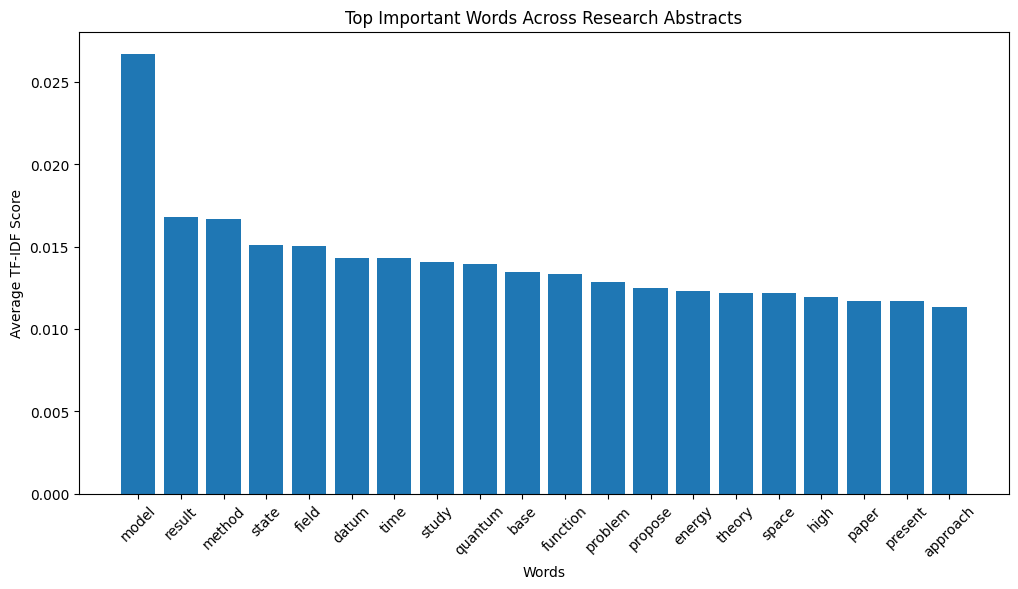

In [8]:
plt.figure(figsize=(12,6))
plt.bar(top_words, top_scores)

plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Average TF-IDF Score")
plt.title("Top Important Words Across Research Abstracts")

plt.show()

In [9]:
sparse.save_npz("tfidf_features.npz", tfidf_matrix)

print("TF-IDF matrix saved successfully")

TF-IDF matrix saved successfully


In [12]:
import json

# Convert numpy int64 values to Python int
vocab = {key: int(value) for key, value in tfidf_vectorizer.vocabulary_.items()}

with open("tfidf_vocab.json", "w") as f:
    json.dump(vocab, f)

print("Vocabulary saved successfully")

Vocabulary saved successfully


In [13]:
import pickle

with open("tfidf_feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print("Feature names saved")

Feature names saved


Word Embeddings using Word2Vec (OPTIONAL)

In [ ]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# Tokenize abstracts
tokenized_abstracts = df_sample['clean_abstract'].apply(word_tokenize)

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=tokenized_abstracts,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4
)

print("Word2Vec model trained.")

In [ ]:
w2v_model.save("word2vec.model")